In [ ]:
import numpy as np  # Data manipulation
import pandas as pd # Dataframe manipulation
import matplotlib.pyplot as plt # Plotting the data and the results
import matplotlib.image as mpimg # For displaying imagees
%matplotlib inline

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [ ]:
size = 249
target_size = (size,size,3)

In [ ]:
train_datagen1 = ImageDataGenerator(horizontal_flip=True,
                                   width_shift_range=0.4,
                                   height_shift_range=0.4,
                                   zoom_range=0.3,
                                   rotation_range=20,
                                   rescale=1./255)

import kagglehub

# Download latest version
path1 = kagglehub.dataset_download("cashutosh/gender-classification-dataset/Training")
path2 = kagglehub.dataset_download("cashutosh/gender-classification-dataset/Validation")

print("Path to dataset files:", path1)

train_gen1 = train_datagen1.flow_from_directory(path1,
                                              target_size=(size,size),
                                              batch_size=32,
                                              class_mode='binary')



100%|██████████| 269M/269M [00:01<00:00, 161MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/cashutosh/gender-classification-dataset/versions/1
Found 58658 images belonging to 2 classes.


In [ ]:
test_datagen1 = ImageDataGenerator(rescale=1./255)

test_gen1 = test_datagen1.flow_from_directory(path1,
                                              target_size=(size,size),
                                              batch_size=32,
                                              class_mode='binary')

Found 58658 images belonging to 2 classes.


In [ ]:
train_datagen2 = ImageDataGenerator(rescale=1./255,
                                    rotation_range=30,
                                    shear_range=0.3,
                                    zoom_range=0.3,
                                    horizontal_flip=True,
                                    #width_shift_range=0.4,
                                    #height_shift_range=0.4,
                                   )

import kagglehub

# Download latest version
path2= kagglehub.dataset_download("ashishjangra27/gender-recognition-200k-images-celeba")

print("Path to dataset files:", path2)


train_gen2 =train_datagen2.flow_from_directory(path2,
                                            target_size=(size,size),
                                            batch_size=64,
                                            class_mode='binary')

100%|██████████| 1.32G/1.32G [00:16<00:00, 86.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ashishjangra27/gender-recognition-200k-images-celeba/versions/1
Found 202599 images belonging to 1 classes.


In [ ]:
valid_datagen2 = ImageDataGenerator(rescale=1./255)

valid_gen2 = valid_datagen2.flow_from_directory(path2,
                                                target_size=(size,size),
                                                batch_size=64,
                                                class_mode='binary')

Found 202599 images belonging to 1 classes.


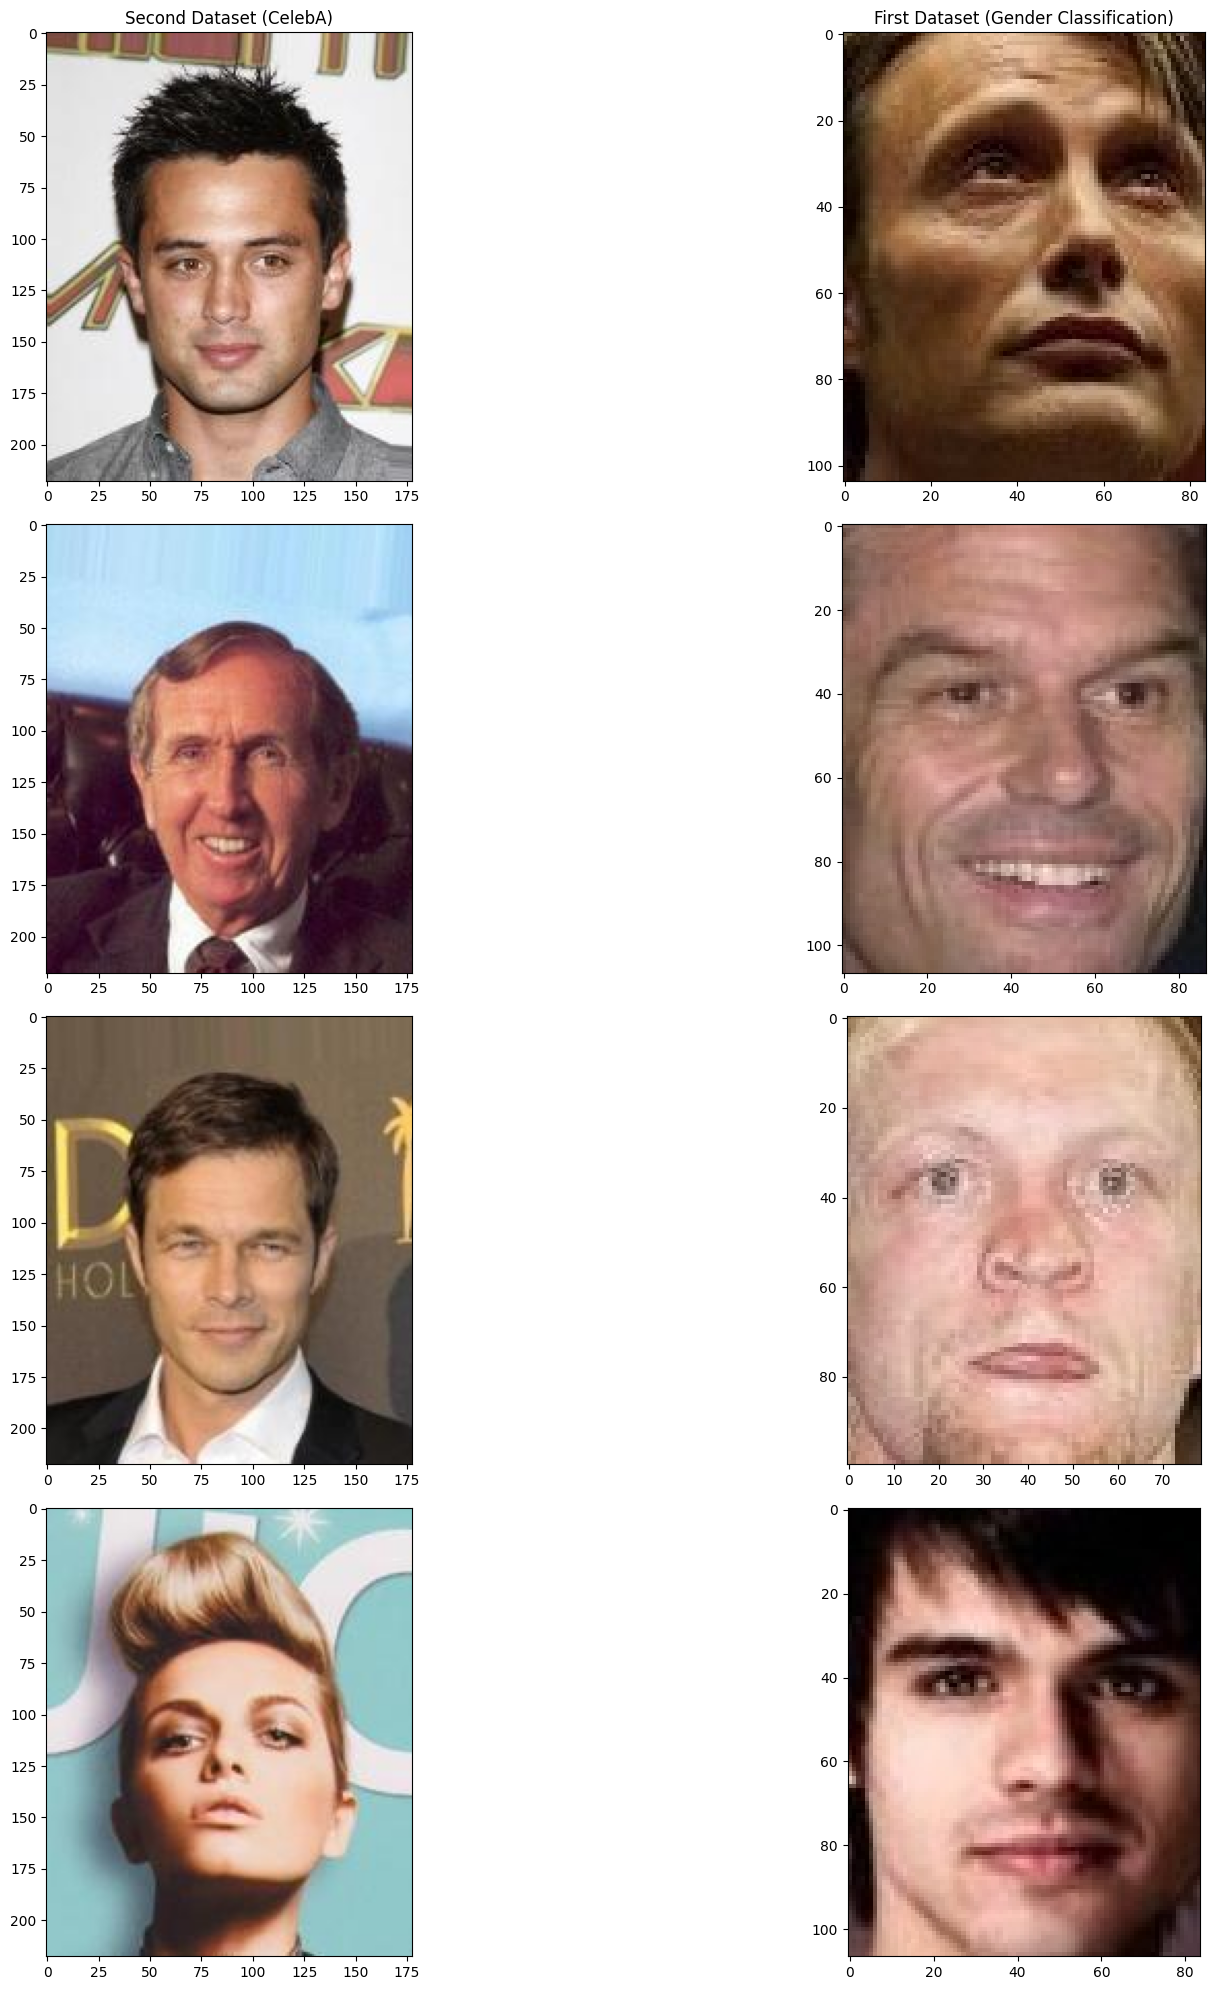

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ✅ Correct dataset paths
#dataset1_path = "/kaggle/input/gender-classification-dataset"
#dataset2_path = "/kaggle/input/gender-recognition-200k-images-celeba"

# ✅ Updated paths based on dataset structure
fig, ax = plt.subplots(ncols=2, nrows=4, figsize=(20, 20))

# Second dataset (CelebA)
img1 = mpimg.imread(f"{path2}/Dataset/Train/Male/000007.jpg")
ax[0][0].imshow(img1)
ax[0][0].set_title("Second Dataset (CelebA)")

# First dataset (Gender Classification)
img2 = mpimg.imread(f"{path1}/Validation/male/063453.jpg.jpg")
ax[0][1].imshow(img2)
ax[0][1].set_title("First Dataset (Gender Classification)")

img3 = mpimg.imread(f"{path2}/Dataset/Train/Male/000021.jpg")
ax[1][0].imshow(img3)

img4 = mpimg.imread(f"{path1}/Validation/male/063495.jpg.jpg")
ax[1][1].imshow(img4)

img5 = mpimg.imread(f"{path2}/Dataset/Train/Male/000033.jpg")
ax[2][0].imshow(img5)

img6 = mpimg.imread(f"{path1}/Validation/male/063517.jpg.jpg")
ax[2][1].imshow(img6)

ax[3][0].imshow(mpimg.imread(f"{path2}/Dataset/Train/Female/000005.jpg"))
ax[3][1].imshow(mpimg.imread(f"{path1}/Validation/male/063531.jpg.jpg"))

plt.tight_layout()
plt.show()


In [ ]:
model = Sequential()
model.add(Xception(include_top=False, pooling='avg', weights='imagenet', input_shape=target_size))
model.add(Flatten())
model.add(BatchNormalization())
#head
model.add(Dense(2048, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())

model.add(Dense(1, activation='sigmoid'))

model.layers[0].trainable = False

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.summary()
model.compile(optimizer= 'Adam', loss = 'binary_crossentropy', metrics= ['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ xception (Functional)                │ (None, 2048)                │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 2048)                │           8,192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 2048)                │       4,196,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 2048)                │           8,192 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1024)                │       2,098,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │           1,025 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,177,513 (103.67 MB)

 Trainable params: 6,305,793 (24.05 MB)

 Non-trainable params: 20,871,720 (79.62 MB)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint('xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',
                                             save_best_only = True,
                                             monitor= 'val_accuracy',
                                             mode = 'max')

In [ ]:
epochs = 12
batch_size=256
history1 = model.fit(train_gen1, epochs= epochs, validation_data= test_gen1,
                    steps_per_epoch= len(train_gen1.filenames)//batch_size,
                    validation_steps= len(test_gen1.filenames)//batch_size,
                    callbacks= [checkpoint]
                    )

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.6611 - loss: 1.0080

229/229 ━━━━━━━━━━━━━━━━━━━━ 180s 711ms/step - accuracy: 0.6615 - loss: 1.0066 - val_accuracy: 0.7994 - val_loss: 0.5159
Epoch 2/2
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.7910 - loss: 0.5366

229/229 ━━━━━━━━━━━━━━━━━━━━ 200s 878ms/step - accuracy: 0.7910 - loss: 0.5366 - val_accuracy: 0.8095 - val_loss: 0.4980


<Figure size 640x480 with 0 Axes>

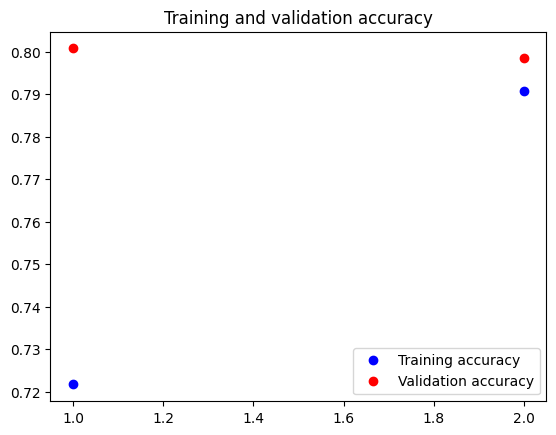

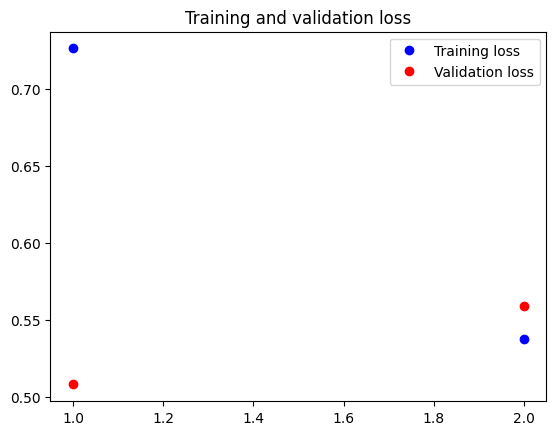

<Figure size 640x480 with 0 Axes>

In [ ]:
acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']
loss = history1.history['loss']
val_loss = history1.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'ro', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'ro', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.figure()

In [ ]:
test_loss, test_acc = model.evaluate(test_gen1, steps=50)
print('test acc:', test_acc)
print('test_loss:',test_loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.7958 - loss: 0.5695
test acc: 0.793749988079071
test_loss: 0.5739273428916931


In [ ]:
test_datagen2 = ImageDataGenerator(rescale=1./255)

test_gen2 = test_datagen2.flow_from_directory(f"{path2}/Dataset/Test",
                                              target_size=(size,size),
                                              batch_size=650,
                                              class_mode='binary')

Found 20001 images belonging to 2 classes.


In [ ]:
!pip install kagglehub
import kagglehub
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ... (rest of your code)

test_datagen2 = ImageDataGenerator(rescale=1./255)

# Reduced batch size to 32
test_gen2 = test_datagen2.flow_from_directory(f"{path2}/Dataset/Test",
                                              target_size=(size,size),
                                              batch_size=32,  # Changed from 650 to 32
                                              class_mode='binary')

test_loss, test_acc = model.evaluate(test_gen2, steps=10)
print('test acc:', test_acc)
print('test_loss:',test_loss)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint('xception_v2_{epoch:02d}_{val_accuracy:.3f}.h5',
                                             save_best_only = True,
                                             monitor= 'val_accuracy',
                                             mode = 'max')

In [ ]:
epochs = 5#should train for 10 epochs
batch_size=512
history2 = model.fit(train_gen2, epochs = epochs, validation_data = valid_gen2,
                    steps_per_epoch= len(train_gen2.filenames)//batch_size,
                    validation_steps= len(valid_gen2.filenames)//batch_size,
                    callbacks= [checkpoint]
                    )

Epoch 1/2
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9975 - loss: 0.0743

395/395 ━━━━━━━━━━━━━━━━━━━━ 543s 1s/step - accuracy: 0.9975 - loss: 0.0742 - val_accuracy: 1.0000 - val_loss: 0.0038
Epoch 2/2
395/395 ━━━━━━━━━━━━━━━━━━━━ 559s 1s/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0013


In [ ]:
test_loss, test_acc = model.evaluate(test_gen1, steps=50)
print('test acc:', test_acc)
print('test_loss:',test_loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.7998 - loss: 1.3685
test acc: 0.8143749833106995
test_loss: 1.2686386108398438


In [ ]:
test_loss, test_acc = model.evaluate(test_gen2, steps=100)
print('test acc:', test_acc)
print('test_loss:',test_loss)

100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.5663 - loss: 2.9104
test acc: 0.5774999856948853
test_loss: 2.835073947906494


Model saved successfully!
